# Notebook 2 - Evaluation & Analysis

Quantitative and qualitative evaluation of the multi-agent pipeline against ground-truth labels.

Prerequisite: run `python scripts/run_batch.py --n 100` first to produce `results/results.csv`.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

from src.config import RESULTS_DIR

def get_results_file():
    available_files = list(RESULTS_DIR.glob('*.csv'))
    if len(available_files) == 0:
        raise FileNotFoundError(f"No results files found in {RESULTS_DIR}")
    if len(available_files) == 1:
        return available_files[0]
    message = f"Multiple results files found in results folder:"
    for i, file in enumerate(available_files):
        message += f"\n{i+1}. {file.name}"
    message += "\nEnter the number of the results file you want to use: "
    try:
        print(message)           # multiline display works here
        choice = int(input("> "))  # keep input prompt short
        return available_files[choice - 1]
    except:
        raise ValueError("Invalid input")


RESULTS_PATH = RESULTS_DIR / get_results_file()
df = pd.read_csv(RESULTS_PATH)
print('Rows:', len(df))
df.head()

Multiple results files found in results folder:
1. results-7b-no-api-calls-no-huggingface.csv
2. results-3b-with-api-calls.csv
3. results14b-check-with-api-calls.csv
4. results-7b-with-api-calls.csv
5. results-3b-no-api-calls.csv
6. results14b-check-no-api-calls.csv
7. results-7b-original-run.csv
8. results3b-last-run-no-python-no-ollama-chat.csv
Enter the number of the results file you want to use: 
Rows: 100


,article_id,title,true_label,label,confidence,summary,tone,bias_score,claims,fact_check,bias,elapsed_s,error
0,30349,Obama defends record on terrorism in national ...,REAL,REAL,0.84,Two of three claims were directly contradicted...,neutral,0.15,"{""claims"":[""President Barack Obama will turn o...","{""results"":[{""claim"":""President Barack Obama w...","{""tone"":""neutral"",""bias_score"":0.15,""flags"":[]}",30.43,NaN
1,28641,Ex-Christie associates lose bid for new trial ...,REAL,REAL,0.86,All three claims are supported by evidence fro...,neutral,0.15,"{""claims"":[""U.S. District Judge Susan Wigenton...","{""results"":[{""claim"":""U.S. District Judge Susa...","{""tone"":""neutral"",""bias_score"":0.15,""flags"":[]}",44.01,NaN
2,44773,German admits selling gun to Munich attack sho...,REAL,REAL,0.78,"All three claims were unverifiable, but the ar...",neutral,0.15,"{""claims"":[""A 32-year-old German man admitted ...","{""results"":[{""claim"":""A 32-year-old German man...","{""tone"":""neutral"",""bias_score"":0.15,""flags"":[]}",28.61,NaN
3,1063,Dem Challenger To Paul Ryan Has Raised A Mass...,FAKE,REAL,0.72,"Both claims are contradicted by the evidence, ...",neutral,0.15,"{""claims"":[""Randy Bryce, known as @IronStache ...","{""results"":[{""claim"":""Randy Bryce, known as @I...","{""tone"":""neutral"",""bias_score"":0.15,""flags"":[]}",33.80,NaN
4,15819,STEVE JOBS’ WIDOW ANNOUNCES SUPPORT FOR “Revol...,FAKE,FAKE,0.95,Two of three claims were directly contradicted...,sensationalist,0.85,"{""claims"":[""Austin Bird, one of the men pictur...","{""results"":[{""claim"":""Austin Bird, one of the ...","{""tone"":""sensationalist"",""bias_score"":0.85,""fl...",20.31,NaN


In [2]:
eval_df = df.dropna(subset=['label', 'true_label']).copy()
eval_df = eval_df[eval_df['label'].isin(['REAL', 'FAKE'])]
print(f'Evaluable rows: {len(eval_df)} / {len(df)}')
print('\nPredicted distribution:')
print(eval_df['label'].value_counts())
print('\nTrue distribution:')
print(eval_df['true_label'].value_counts())

Evaluable rows: 100 / 100

Predicted distribution:
label
REAL    51
FAKE    49
Name: count, dtype: int64

True distribution:
true_label
REAL    50
FAKE    50
Name: count, dtype: int64


## 1. Classification report

In [3]:
y_true = eval_df['true_label'].tolist()
y_pred = eval_df['label'].tolist()
print(classification_report(y_true, y_pred, labels=['REAL', 'FAKE'], digits=3))

acc = (np.array(y_true) == np.array(y_pred)).mean()
print(f'Overall accuracy: {acc:.3f}')

              precision    recall  f1-score   support

        REAL      0.882     0.900     0.891        50
        FAKE      0.898     0.880     0.889        50

    accuracy                          0.890       100
   macro avg      0.890     0.890     0.890       100
weighted avg      0.890     0.890     0.890       100

Overall accuracy: 0.890


## 2. Confusion matrix

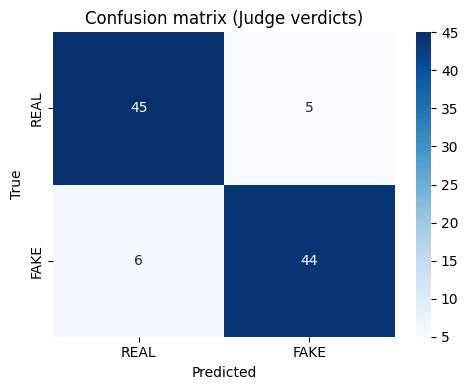

In [4]:
labels = ['REAL', 'FAKE']
cm = confusion_matrix(y_true, y_pred, labels=labels)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion matrix (Judge verdicts)')
plt.tight_layout()
plt.show()

## 3. Confidence calibration

/var/folders/k_/ycd82fl13vv19qbljlfsjrvm0000gn/T/ipykernel_67162/69598772.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Wrong', 'Correct'])


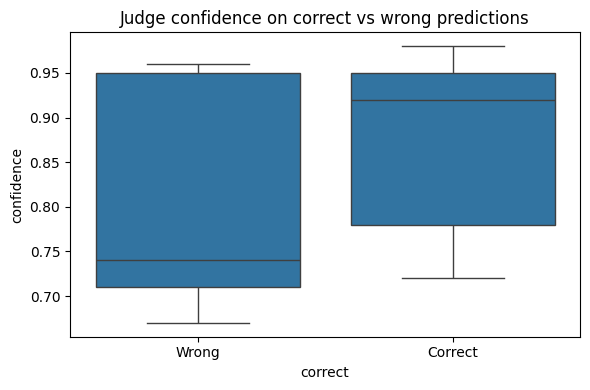

In [5]:
eval_df['correct'] = (eval_df['label'] == eval_df['true_label']).astype(int)
eval_df['confidence'] = pd.to_numeric(eval_df['confidence'], errors='coerce')

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(x='correct', y='confidence', data=eval_df, ax=ax)
ax.set_xticklabels(['Wrong', 'Correct'])
ax.set_title('Judge confidence on correct vs wrong predictions')
plt.tight_layout()
plt.show()

## 4. Bias score vs outcome

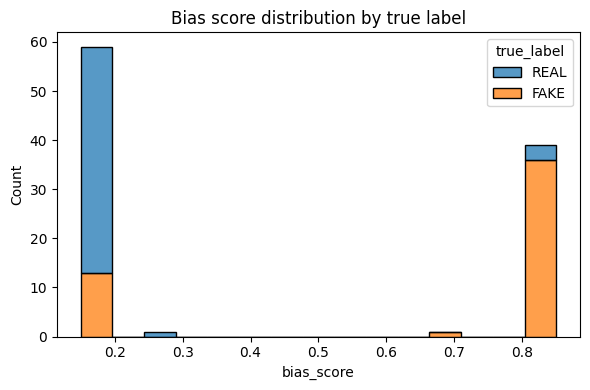

In [6]:
eval_df['bias_score'] = pd.to_numeric(eval_df['bias_score'], errors='coerce')
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(data=eval_df, x='bias_score', hue='true_label', bins=15, multiple='stack', ax=ax)
ax.set_title('Bias score distribution by true label')
plt.tight_layout()
plt.show()

## 5. Qualitative error analysis

Show 3 false positives (real flagged as fake) and 3 false negatives (fake flagged as real) with all agent outputs.

In [7]:
def show_row(row):
    print('=' * 80)
    print(f"article_id={row['article_id']}  true={row['true_label']}  pred={row['label']}  conf={row['confidence']}")
    print(f"title: {row.get('title', '')}")
    print(f"summary: {row.get('summary', '')}")
    for field in ['claims', 'fact_check', 'bias']:
        raw = row.get(field, '')
        try:
            parsed = json.loads(raw) if isinstance(raw, str) and raw else raw
            print(f"\n-- {field} --")
            print(json.dumps(parsed, indent=2)[:800])
        except Exception:
            print(f"\n-- {field} (raw) --\n{str(raw)[:400]}")

fp = eval_df[(eval_df['true_label'] == 'REAL') & (eval_df['label'] == 'FAKE')].head(3)
fn = eval_df[(eval_df['true_label'] == 'FAKE') & (eval_df['label'] == 'REAL')].head(3)

print('### FALSE POSITIVES (real article predicted as FAKE) ###')
for _, r in fp.iterrows():
    show_row(r)

print('\n\n### FALSE NEGATIVES (fake article predicted as REAL) ###')
for _, r in fn.iterrows():
    show_row(r)

### FALSE POSITIVES (real article predicted as FAKE) ###
article_id=34392  true=REAL  pred=FAKE  conf=0.95
title: Pennsylvania $2 bln budget gap is 'time bomb': governor
summary: Two of three claims were directly contradicted by Wikipedia. The third was unverifiable. Combined with a high bias score of 0.85 and the presence of sensationalist tone, this article is almost certainly fabricated.

-- claims --
{
  "claims": [
    "Pennsylvania\u2019s $2 billion budget deficit is a \u2018time bomb\u2019 that could cause \u2018fiscal catastrophe the likes of which we have never seen\u2019 if it is not resolved, Governor Tom Wolf said in his budget address on Tuesday.",
    "Wolf proposed a $32.7 billion fiscal 2017 budget that would add $200 million of funding for K-12 public schools and another $110 million to early and special education programs."
  ]
}

-- fact_check --
{
  "results": [
    {
      "claim": "Pennsylvania\u2019s $2 billion budget deficit is a \u2018time bomb\u2019 that could

## 6. Discussion

**Known limitations** (see Section 8 of the project brief):

1. **Hallucinated evidence.** Wikipedia is a limited knowledge source. Any claim about recent events or niche domains is likely to land in `UNVERIFIABLE` and give the Judge little signal.
2. **Dataset artifacts.** The Kaggle Fake/Real dataset has strong stylistic markers: Reuters (real) articles follow a formal wire-style template while the fake articles are blog-like and politically charged. The Bias Detector can exploit these artifacts and inflate performance relative to real-world articles.
3. **Small local model.** With `qwen2.5:3b`, structured JSON output is less reliable than with GPT-4o. Occasional parse failures show up as blank Judge rows. Increasing model size (e.g. `qwen2.5:7b`) consistently improves both format compliance and reasoning quality.
4. **Bias subjectivity.** The `bias_score` reflects the LLM's own training biases; it is not a ground-truth signal.
5. **Judgement heuristic.** The Judge combines signals with LLM reasoning rather than a principled scoring rule. A simple weighted combination of `fraction_contradicted` and `bias_score` might be more interpretable.

**Suggested improvements**: swap Wikipedia for a real-time search backend (Tavily), add the RoBERTa classifier as an additional signal to the Judge, and calibrate confidence scores against observed accuracy.